<a href="https://colab.research.google.com/github/manavdhelia/ML-for-engineers/blob/HW4/hw4_p2_ablation_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECE 601 — HW4 Problem 2: Ablation Study
## Regularization techniques on the best classifier from Problem 1
**Baseline:** 1 hidden layer (256 units), ReLU, Adam — UMass Amherst Spring 2026

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
BATCH_SIZE = 64
train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)
print(f'Train: {len(train_dataset):,} | Test: {len(test_dataset):,}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.91MB/s]

Train: 60,000 | Test: 10,000


In [3]:
NUM_EPOCHS = 10

def train_epoch(model, loader, criterion, optimizer, noise_std=0.0):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        if noise_std > 0:
            images = images + torch.randn_like(images) * noise_std
        optimizer.zero_grad()
        out  = model(images)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += out.max(1)[1].eq(labels).sum().item()
        total      += labels.size(0)
    return total_loss / total, 100. * correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            out  = model(images)
            loss = criterion(out, labels)
            total_loss += loss.item() * images.size(0)
            correct    += out.max(1)[1].eq(labels).sum().item()
            total      += labels.size(0)
    return total_loss / total, 100. * correct / total

def run_experiment(model, label, noise_std=0.0, lr=1e-3, weight_decay=0.0):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history   = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

    print(f'\n--- {label} ---')
    print(f'{"Ep":>3} | {"Tr Loss":>8} | {"Tr Acc":>7} | {"Val Acc":>7}')
    print('-'*35)
    for epoch in range(1, NUM_EPOCHS + 1):
        tl, ta = train_epoch(model, train_loader, criterion, optimizer, noise_std)
        vl, va = evaluate(model, test_loader, criterion)
        history['train_loss'].append(tl); history['train_acc'].append(ta)
        history['val_loss'].append(vl);   history['val_acc'].append(va)
        print(f'{epoch:>3} | {tl:>8.4f} | {ta:>6.2f}% | {va:>6.2f}%')
    print(f'Best val acc: {max(history["val_acc"]):.2f}%')
    return history

print('Helpers defined.')

Helpers defined.


## Baseline — no regularization
The best model from Problem 1(a): one hidden layer of 256 units, ReLU, Adam.

In [4]:
class BaselineNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )
    def forward(self, x): return self.net(x)

results = {}
results['Baseline'] = run_experiment(BaselineNet().to(device), 'Baseline (no reg)')


--- Baseline (no reg) ---
 Ep |  Tr Loss |  Tr Acc | Val Acc
-----------------------------------
  1 |   0.2259 |  93.28% |  96.32%
  2 |   0.0946 |  97.16% |  97.27%
  3 |   0.0631 |  98.03% |  97.83%
  4 |   0.0470 |  98.53% |  97.61%
  5 |   0.0377 |  98.74% |  97.55%
  6 |   0.0299 |  98.99% |  97.55%
  7 |   0.0257 |  99.13% |  97.71%
  8 |   0.0193 |  99.36% |  98.05%
  9 |   0.0191 |  99.35% |  97.82%
 10 |   0.0161 |  99.46% |  97.88%
Best val acc: 98.05%


## (a) Weight decay (L2 regularization)
Weight decay is passed directly to Adam via the `weight_decay` argument.  
We try λ = 1e-4, 1e-3, 1e-2 and pick the best.

In [5]:
wd_values = [1e-4, 1e-3, 1e-2]
best_wd_val, best_wd_lam = 0, None

for lam in wd_values:
    h = run_experiment(BaselineNet().to(device),
                       label=f'Weight decay λ={lam}',
                       weight_decay=lam)
    val = max(h['val_acc'])
    if val > best_wd_val:
        best_wd_val, best_wd_lam = val, lam
        results['Weight decay'] = h

print(f'\nBest weight decay: λ={best_wd_lam}  val acc={best_wd_val:.2f}%')


--- Weight decay λ=0.0001 ---
 Ep |  Tr Loss |  Tr Acc | Val Acc
-----------------------------------
  1 |   0.2290 |  93.22% |  96.11%
  2 |   0.0984 |  97.03% |  96.99%
  3 |   0.0677 |  97.89% |  97.54%
  4 |   0.0522 |  98.38% |  97.86%
  5 |   0.0429 |  98.63% |  97.53%
  6 |   0.0346 |  98.90% |  97.76%
  7 |   0.0313 |  99.01% |  97.64%
  8 |   0.0293 |  99.00% |  98.12%
  9 |   0.0258 |  99.12% |  97.12%
 10 |   0.0241 |  99.17% |  97.58%
Best val acc: 98.12%

--- Weight decay λ=0.001 ---
 Ep |  Tr Loss |  Tr Acc | Val Acc
-----------------------------------
  1 |   0.2292 |  93.28% |  96.39%
  2 |   0.1098 |  96.74% |  96.89%
  3 |   0.0884 |  97.34% |  96.98%
  4 |   0.0790 |  97.62% |  96.99%
  5 |   0.0730 |  97.77% |  97.30%
  6 |   0.0664 |  97.95% |  97.56%
  7 |   0.0667 |  97.99% |  97.38%
  8 |   0.0627 |  98.11% |  97.08%
  9 |   0.0606 |  98.15% |  97.76%
 10 |   0.0585 |  98.26% |  97.68%
Best val acc: 97.76%

--- Weight decay λ=0.01 ---
 Ep |  Tr Loss |  Tr Acc |

## (b) Input noise injection
Zero-mean Gaussian noise is added to each image at every training step.  
We try σ = 0.1, 0.2, 0.3 — noise is only applied during training, not evaluation.

In [6]:
noise_values = [0.1, 0.2, 0.3]
best_ni_val, best_ni_sig = 0, None

for sigma in noise_values:
    h = run_experiment(BaselineNet().to(device),
                       label=f'Noise σ={sigma}',
                       noise_std=sigma)
    val = max(h['val_acc'])
    if val > best_ni_val:
        best_ni_val, best_ni_sig = val, sigma
        results['Noise injection'] = h

print(f'\nBest noise: σ={best_ni_sig}  val acc={best_ni_val:.2f}%')


--- Noise σ=0.1 ---
 Ep |  Tr Loss |  Tr Acc | Val Acc
-----------------------------------
  1 |   0.2309 |  93.10% |  95.70%
  2 |   0.0952 |  97.15% |  97.27%
  3 |   0.0635 |  98.04% |  97.18%
  4 |   0.0490 |  98.44% |  97.68%
  5 |   0.0364 |  98.80% |  97.47%
  6 |   0.0301 |  99.05% |  97.69%
  7 |   0.0271 |  99.10% |  98.04%
  8 |   0.0216 |  99.28% |  97.57%
  9 |   0.0194 |  99.36% |  97.97%
 10 |   0.0182 |  99.36% |  98.11%
Best val acc: 98.11%

--- Noise σ=0.2 ---
 Ep |  Tr Loss |  Tr Acc | Val Acc
-----------------------------------
  1 |   0.2292 |  93.19% |  96.53%
  2 |   0.0963 |  97.08% |  97.19%
  3 |   0.0668 |  97.88% |  97.35%
  4 |   0.0493 |  98.40% |  97.90%
  5 |   0.0391 |  98.70% |  97.62%
  6 |   0.0311 |  98.98% |  97.66%
  7 |   0.0280 |  99.04% |  97.74%
  8 |   0.0217 |  99.27% |  98.09%
  9 |   0.0205 |  99.26% |  97.81%
 10 |   0.0197 |  99.33% |  98.16%
Best val acc: 98.16%

--- Noise σ=0.3 ---
 Ep |  Tr Loss |  Tr Acc | Val Acc
------------------

## (c) Dropout
`nn.Dropout(p)` is inserted after the ReLU in the hidden layer.  
During training it randomly zeros activations with probability p.  
At test time PyTorch automatically disables dropout (model.eval()).  
We try p = 0.2, 0.5, 0.8.

In [9]:
class DropoutNet(nn.Module):
    def __init__(self, p=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Dropout(p=p),
            nn.Linear(256, 10)
        )
    def forward(self, x): return self.net(x)

dropout_values = [0.2, 0.5, 0.8]
best_do_val, best_do_p = 0, None

for p in dropout_values:
    h = run_experiment(DropoutNet(p=p).to(device), label=f'Dropout p={p}')
    val = max(h['val_acc'])
    if val > best_do_val:
        best_do_val, best_do_p = val, p
        results['Dropout'] = h

print(f'\nBest dropout: p={best_do_p}  val acc={best_do_val:.2f}%')


--- Dropout p=0.2 ---
 Ep |  Tr Loss |  Tr Acc | Val Acc
-----------------------------------
  1 |   0.2489 |  92.74% |  95.99%
  2 |   0.1161 |  96.45% |  97.14%
  3 |   0.0871 |  97.30% |  97.57%
  4 |   0.0718 |  97.69% |  97.53%
  5 |   0.0608 |  98.05% |  97.75%
  6 |   0.0535 |  98.27% |  97.79%
  7 |   0.0451 |  98.47% |  97.80%
  8 |   0.0431 |  98.58% |  97.92%
  9 |   0.0394 |  98.67% |  97.83%
 10 |   0.0359 |  98.75% |  98.00%
Best val acc: 98.00%

--- Dropout p=0.5 ---
 Ep |  Tr Loss |  Tr Acc | Val Acc
-----------------------------------
  1 |   0.3189 |  90.42% |  95.77%
  2 |   0.1778 |  94.63% |  96.95%
  3 |   0.1461 |  95.53% |  97.39%
  4 |   0.1302 |  96.06% |  97.34%
  5 |   0.1193 |  96.30% |  97.44%
  6 |   0.1117 |  96.52% |  97.84%
  7 |   0.1023 |  96.79% |  97.76%
  8 |   0.1015 |  96.87% |  97.88%
  9 |   0.0939 |  96.99% |  97.93%
 10 |   0.0853 |  97.26% |  97.77%
Best val acc: 97.93%

--- Dropout p=0.8 ---
 Ep |  Tr Loss |  Tr Acc | Val Acc
------------

## (d) Batch normalization
`nn.BatchNorm1d` is inserted between the linear transform and the ReLU activation,  
normalizing each mini-batch to zero mean and unit variance (Lecture 11, Section 5).

In [10]:
class BatchNormNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )
    def forward(self, x): return self.net(x)

results['Batch norm'] = run_experiment(BatchNormNet().to(device), 'Batch normalization')


--- Batch normalization ---
 Ep |  Tr Loss |  Tr Acc | Val Acc
-----------------------------------
  1 |   0.2274 |  93.64% |  96.52%
  2 |   0.1015 |  97.02% |  97.54%
  3 |   0.0702 |  97.93% |  97.49%
  4 |   0.0527 |  98.42% |  97.86%
  5 |   0.0423 |  98.69% |  97.84%
  6 |   0.0327 |  99.01% |  98.12%
  7 |   0.0275 |  99.18% |  97.94%
  8 |   0.0223 |  99.33% |  97.96%
  9 |   0.0210 |  99.33% |  98.12%
 10 |   0.0171 |  99.46% |  98.11%
Best val acc: 98.12%


## Summary — all techniques compared

In [11]:
print(f'{"Technique":<22} | {"Best Val Acc":>12} | {"Final Val Acc":>13} | {"Final Train Acc":>15}')
print('-'*70)
for name, h in results.items():
    print(f'{name:<22} | {max(h["val_acc"]):>11.2f}% | {h["val_acc"][-1]:>12.2f}% | {h["train_acc"][-1]:>14.2f}%')

Technique              | Best Val Acc | Final Val Acc | Final Train Acc
----------------------------------------------------------------------
Baseline               |       98.05% |        97.88% |          99.46%
Weight decay           |       98.12% |        97.58% |          99.17%
Noise injection        |       98.16% |        98.16% |          99.33%
Dropout                |       98.00% |        98.00% |          98.75%
Batch norm             |       98.12% |        98.11% |          99.46%


## Learning curves — all techniques

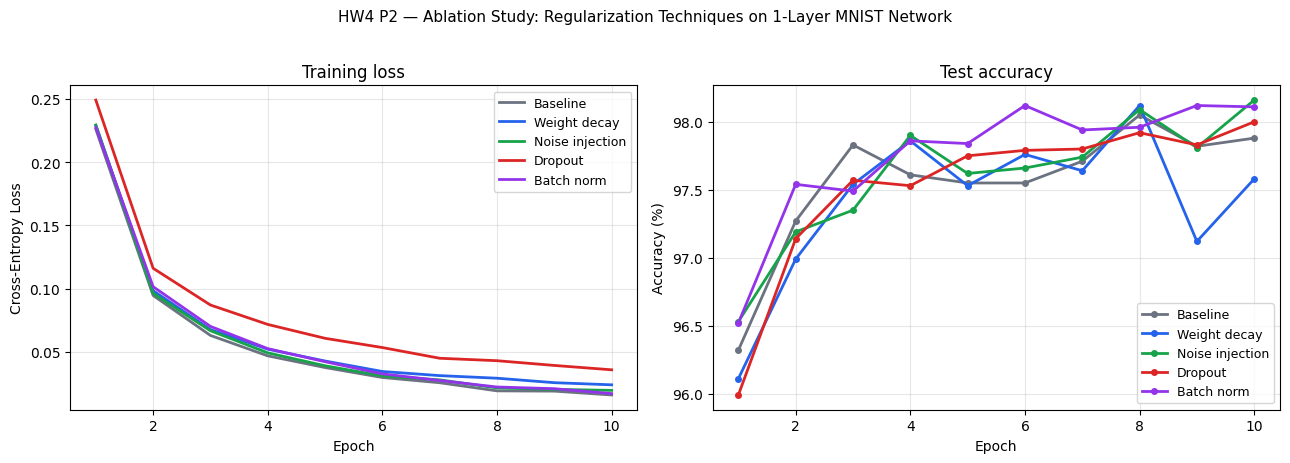

Figure saved as hw4_p2_ablation.png


In [12]:
colors = {'Baseline':'#6b7280','Weight decay':'#2563eb',
          'Noise injection':'#16a34a','Dropout':'#dc2626','Batch norm':'#9333ea'}
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

for name, h in results.items():
    ax1.plot(epochs, h['train_loss'], color=colors[name], linewidth=2, label=name)
    ax2.plot(epochs, h['val_acc'],   color=colors[name], linewidth=2,
             marker='o', markersize=4, label=name)

ax1.set_title('Training loss');    ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss'); ax1.legend(fontsize=9); ax1.grid(alpha=0.3)
ax2.set_title('Test accuracy');    ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)');   ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.suptitle('HW4 P2 — Ablation Study: Regularization Techniques on 1-Layer MNIST Network',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('hw4_p2_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as hw4_p2_ablation.png')